In [1]:
import os
from pathlib import Path
from natsort import natsorted
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
import torch.optim as optim

from typing import List, Tuple, Dict
from dataclasses import dataclass
import json

print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

PyTorch version: 2.11.0.dev20260116+cu128
CUDA available: True


In [2]:
def compute_all_metrics(preds_sigmoid, targets, threshold=0.5, smooth=1e-6):
    preds_bin = (preds_sigmoid > threshold).float()
    preds_flat  = preds_bin.view(preds_bin.size(0), -1)
    target_flat = targets.view(targets.size(0), -1)

    tp = (preds_flat * target_flat).sum(dim=1)
    fp = (preds_flat * (1 - target_flat)).sum(dim=1)
    fn = ((1 - preds_flat) * target_flat).sum(dim=1)

    intersection = tp
    union = preds_flat.sum(dim=1) + target_flat.sum(dim=1) - intersection

    dice      = (2.0 * intersection + smooth) / (preds_flat.sum(dim=1) + target_flat.sum(dim=1) + smooth)
    iou       = (intersection + smooth) / (union + smooth)
    precision = (tp + smooth) / (tp + fp + smooth)
    recall    = (tp + smooth) / (tp + fn + smooth)

    return {
        'dice':      dice.mean().item(),
        'iou':       iou.mean().item(),
        'precision': precision.mean().item(),
        'recall':    recall.mean().item()}

In [3]:
class AsymmetricSimilarityLoss(nn.Module):
    """
    Density-aware Asymmetric Similarity Loss.

    alpha : FN penalty weight — higher alpha = more sensitive (don't miss positives)
    beta  : FP penalty weight — higher beta  = more conservative (avoid false alarms)
    alpha + beta should sum to 1.0

    Density behaviour:
        low density     → balanced α/β       (conservative — structures less likely real)
        medium density  → slightly higher α  (mild recall bias)
        high density    → higher α, lower β  (sensitive — don't miss structures in dense regions)
        negative        → balanced α/β       (all-background tiles)
    """

    DENSITY_PARAMS = {
        0: (0.5, 0.5),   # low      — balanced
        1: (0.6, 0.4),   # medium   — mild recall bias
        2: (0.7, 0.3),   # high     — recall-biased, penalise FN heavily
        3: (0.5, 0.5),   # negative — balanced
    }


    def __init__(self, smooth: float = 1e-6):
        super().__init__()
        self.smooth = smooth

    def forward(self, logits: torch.Tensor,
                targets: torch.Tensor,
                density_labels: torch.Tensor) -> torch.Tensor:
        """
        logits         : [B, 1, H, W]  raw model output (pre-sigmoid)
        targets        : [B, 1, H, W]  binary masks
        density_labels : [B]           long tensor, density class per tile
        """
        probs = torch.sigmoid(logits)

        if targets.dim() == 3:
            targets = targets.unsqueeze(1)

        dims = (1, 2, 3)
        tp = (probs * targets).sum(dims)
        fp = (probs * (1 - targets)).sum(dims)
        fn = ((1 - probs) * targets).sum(dims)

        # Build per-sample alpha/beta tensors from density labels
        alpha = torch.zeros(logits.size(0), device=logits.device)
        beta  = torch.zeros(logits.size(0), device=logits.device)

        for density_idx, (a, b) in self.DENSITY_PARAMS.items():
            mask      = (density_labels == density_idx)
            alpha[mask] = a
            beta[mask]  = b

        # Asymmetric similarity index per sample
        similarity = (tp + self.smooth) / (
            tp + alpha * fn + beta * fp + self.smooth
        )

        loss = (1.0 - similarity)
        return loss.mean()

In [4]:
class CombinedLoss(nn.Module):
    """
    Combines segmentation loss and density classification loss.
    density_weight controls how much the classification head
    contributes to the total gradient — start low since
    segmentation is the primary task.
    """
    def __init__(self, density_weight: float = 0.3):
        super().__init__()
        self.seg_loss      = AsymmetricSimilarityLoss()
        self.density_loss  = nn.CrossEntropyLoss()
        self.density_weight = density_weight

    def forward(self, seg_logits, density_logits, targets, density_labels, aux3, aux2):
        l_seg     = self.seg_loss(seg_logits, targets, density_labels)
        l_density = self.density_loss(density_logits, density_labels)
        
        aux3_up = F.interpolate(aux3, size=targets.shape[2:], mode='bilinear', align_corners=False)
        aux2_up = F.interpolate(aux2, size=targets.shape[2:], mode='bilinear', align_corners=False)
        l_aux = 0.3 * self.seg_loss(aux3_up, targets, density_labels) \
              + 0.1 * self.seg_loss(aux2_up, targets, density_labels)
        return l_seg + self.density_weight * l_density, l_seg, l_density

In [5]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class ResidualBlock(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.conv1 = nn.Conv2d(in_ch, out_ch, 3, padding=1)
        self.bn1   = nn.BatchNorm2d(out_ch)
        self.conv2 = nn.Conv2d(out_ch, out_ch, 3, padding=1)
        self.bn2   = nn.BatchNorm2d(out_ch)
        self.relu  = nn.ReLU(inplace=True)
        self.skip  = nn.Sequential()
        if in_ch != out_ch:
            self.skip = nn.Sequential(
                nn.Conv2d(in_ch, out_ch, 1),
                nn.BatchNorm2d(out_ch)
            )

    def forward(self, x):
        residual = self.skip(x)
        out = self.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        return self.relu(out + residual)


class AttentionGate(nn.Module):
    def __init__(self, F_g, F_l, F_int):
        super().__init__()
        self.W_g  = nn.Sequential(nn.Conv2d(F_g, F_int, 1), nn.BatchNorm2d(F_int))
        self.W_x  = nn.Sequential(nn.Conv2d(F_l, F_int, 1), nn.BatchNorm2d(F_int))
        self.psi  = nn.Sequential(nn.Conv2d(F_int, 1, 1),   nn.BatchNorm2d(1), nn.Sigmoid())
        self.relu = nn.ReLU(inplace=True)

    def forward(self, g, x):
        return x * self.psi(self.relu(self.W_g(g) + self.W_x(x)))


class DensityEmbedding(nn.Module):
    """
    Learns a per-density-class bias that is added to the bottleneck
    feature map. This gives the attention gates an explicit signal about
    the density regime before decoding begins.

    num_classes : number of density classes (low/medium/high/negative = 4)
    bottleneck_ch : channels at bottleneck (1024 in your architecture)
    """
    def __init__(self, num_classes: int = 4, bottleneck_ch: int = 1024):
        super().__init__()
        # Small MLP: class index → embedding vector of size bottleneck_ch
        self.embed = nn.Sequential(
            nn.Embedding(num_classes, 128),   # sparse lookup
            nn.Flatten(),
            nn.Linear(128, bottleneck_ch),
            nn.ReLU(inplace=True),
            nn.Linear(bottleneck_ch, bottleneck_ch),
        )

    def forward(self, density_label: torch.Tensor, spatial_shape: tuple):
        """
        density_label : LongTensor [B]
        spatial_shape : (H, W) of the bottleneck feature map
        Returns       : [B, bottleneck_ch, H, W] bias to add to bottleneck
        """
        emb = self.embed(density_label)
        # Broadcast across spatial dims → [B, 1024, H, W]
        return emb.unsqueeze(-1).unsqueeze(-1).expand(-1, -1, *spatial_shape)

class ResidualAttentionUNet(nn.Module):
    def __init__(self, in_ch=3, out_ch=1, num_density_classes=4):
        super().__init__()

        # Encoder
        self.enc1 = ResidualBlock(in_ch, 64)
        self.enc2 = ResidualBlock(64, 128)
        self.enc3 = ResidualBlock(128, 256)
        self.enc4 = ResidualBlock(256, 512)

        # Bottleneck
        self.bottleneck = ResidualBlock(512, 1024)

        # Density conditioning injected at bottleneck
        self.density_embed = DensityEmbedding(
            num_classes=num_density_classes, bottleneck_ch=1024)

        # Attention gates
        self.att4 = AttentionGate(F_g=512,  F_l=512,  F_int=256)
        self.att3 = AttentionGate(F_g=256,  F_l=256,  F_int=128)
        self.att2 = AttentionGate(F_g=128,  F_l=128,  F_int=64)
        self.att1 = AttentionGate(F_g=64,   F_l=64,   F_int=32)

        # Decoder
        self.upconv4 = nn.ConvTranspose2d(1024, 512, 2, stride=2)
        self.dec4    = ResidualBlock(1024, 512)

        self.upconv3 = nn.ConvTranspose2d(512, 256, 2, stride=2)
        self.dec3    = ResidualBlock(512, 256)

        self.upconv2 = nn.ConvTranspose2d(256, 128, 2, stride=2)
        self.dec2    = ResidualBlock(256, 128)

        self.upconv1 = nn.ConvTranspose2d(128, 64, 2, stride=2)
        self.dec1    = ResidualBlock(128, 64)

        self.out  = nn.Conv2d(64, out_ch, 1)
        self.pool = nn.MaxPool2d(2)

        # Density classification head — reads raw bottleneck before embedding
        # Used at inference to self-predict density in a single forward pass
        self.density_head = nn.Sequential(
        nn.AdaptiveAvgPool2d(1),   # [B, 1024, H, W] → [B, 1024, 1, 1]
        nn.Flatten(),               # → [B, 1024]
        nn.Linear(1024, 256),
        nn.ReLU(inplace=True),
        nn.Linear(256, num_density_classes)  # → [B, num_density_classes]
        )
        self.dropout = nn.Dropout(p=0.3)
        self.aux_head3 = nn.Conv2d(256, 1, 1)  # <-- add these two
        self.aux_head2 = nn.Conv2d(128, 1, 1)  
        
        
    def forward(self, x, density_label=None):
        """
        x             : [B, 3, H, W]
        density_label : [B] long tensor at training time, None at inference

        Returns:
            seg_logits     : [B, 1, H, W]  segmentation output
            density_logits : [B, 4]        density class prediction
        """
        # Encoder
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool(e1))
        e3 = self.enc3(self.pool(e2))
        e4 = self.enc4(self.pool(e3))
    
        # Bottleneck
        b = self.bottleneck(self.pool(e4))
    
        # Classification head reads raw bottleneck
        density_logits = self.density_head(b)  # [B, 4]
    
        # Density conditioning
        # Training: use ground truth label (teacher forcing)
        # Inference: use self-predicted label
        if density_label is None:
            conditioning_label = density_logits.argmax(dim=1)
        else:
            conditioning_label = density_label
    
        b = b + self.density_embed(conditioning_label, b.shape[2:])
        b = self.dropout(b)
        # Decoder
        d4 = self.upconv4(b)
        d4 = self.dec4(torch.cat([d4, self.att4(g=d4, x=e4)], dim=1))
    
        d3 = self.upconv3(d4)
        d3 = self.dec3(torch.cat([d3, self.att3(g=d3, x=e3)], dim=1))
    
        d2 = self.upconv2(d3)
        d2 = self.dec2(torch.cat([d2, self.att2(g=d2, x=e2)], dim=1))
    
        d1 = self.upconv1(d2)
        d1 = self.dec1(torch.cat([d1, self.att1(g=d1, x=e1)], dim=1))
    
        return self.out(d1), density_logits, self.aux_head3(d3), self.aux_head2(d2)
    
    def mc_forward(self, x, n_passes=15):
        self.train()  # enables dropout
        with torch.no_grad():
            passes = torch.stack([self.forward(x)[0] for _ in range(n_passes)])
        self.eval()
        probs = torch.sigmoid(passes)
        return probs.mean(0), probs.var(0)  # mean prediction, uncertainty map

# ── Sanity check ─────────────────────────────────────────────────────────────
if __name__ == "__main__":
    model  = ResidualAttentionUNet(in_ch=3, out_ch=1, num_density_classes=4)
    x      = torch.randn(2, 3, 512, 512)
    labels = torch.tensor([0, 2], dtype=torch.long)
    seg_out, density_out, aux3, aux2 = model(x, labels)  # was seg_out, density_out = ...
    print(f"Input          : {x.shape}")
    print(f"Seg output     : {seg_out.shape}")       # [2, 1, 512, 512]
    print(f"Density output : {density_out.shape}")   # [2, 4]
    print(f"Aux3 output    : {aux3.shape}")           # [2, 1, 32, 32]
    print(f"Aux2 output    : {aux2.shape}")           # [2, 1, 64, 64]
    print(f"Params         : {sum(p.numel() for p in model.parameters()):,}")

Input          : torch.Size([2, 3, 512, 512])
Seg output     : torch.Size([2, 1, 512, 512])
Density output : torch.Size([2, 4])
Aux3 output    : torch.Size([2, 1, 128, 128])
Aux2 output    : torch.Size([2, 1, 256, 256])
Params         : 34,242,739


In [6]:
DENSITY_LABELS = {"low": 0, "medium": 1, "high": 2, "negative": 3}
DENSITY_FOLDERS = list(DENSITY_LABELS.keys())  # folder names to scan

@dataclass
class TilePair:
    """Immutable record of a single image-mask pair with WSI identity and density class"""
    image_path: Path
    mask_path:  Path
    wsi_id:     str
    tile_id:    str
    density:    str = "unknown"   # low | medium | high | negative


class WSIDatasetIndex:
    """
    Builds and validates an index of WSI tile pairs.
    Expects density-stratified folder structure per WSI:
        <wsi_folder>/<density>/images/*.png
        <wsi_folder>/<density>/masks/*_mask.png
    where <density> is one of: high, medium, low, negative
    """

    def __init__(self, export_root: Path, strict_mode: bool = True,
                 allow_size_mismatch: bool = False):
        self.export_root       = Path(export_root)
        self.strict_mode       = strict_mode
        self.allow_size_mismatch = allow_size_mismatch
        self.tile_pairs: List[TilePair] = []
        self.wsi_groups: Dict[str, List[TilePair]] = {}
        self.validation_report: Dict = {
            'total_wsis_found': 0,
            'valid_wsis':       0,
            'skipped_wsis':     [],
            'total_pairs':      0,
            'density_counts':   {d: 0 for d in DENSITY_FOLDERS},
            'issues':           []
        }

    def build_index(self) -> 'WSIDatasetIndex':
        """Build the dataset index with full validation"""
        print("="*60)
        print("Building WSI Dataset Index...")
        print("="*60)

        if not self.export_root.exists():
            raise FileNotFoundError(f"Export root not found: {self.export_root}")

        wsi_folders = [d for d in self.export_root.iterdir() if d.is_dir()]
        self.validation_report['total_wsis_found'] = len(wsi_folders)

        for wsi_folder in wsi_folders:
            try:
                pairs = self._process_wsi_folder(wsi_folder)
                if pairs:
                    self.tile_pairs.extend(pairs)
                    self.wsi_groups[wsi_folder.name] = pairs
                    self.validation_report['valid_wsis'] += 1
                    for p in pairs:
                        self.validation_report['density_counts'][p.density] += 1
            except Exception as e:
                if self.strict_mode:
                    raise
                else:
                    self.validation_report['skipped_wsis'].append(
                        {'wsi_id': wsi_folder.name, 'reason': str(e)})
                    print(f"\u26a0\ufe0f  Skipping {wsi_folder.name}: {e}")

        self.validation_report['total_pairs'] = len(self.tile_pairs)
        self._print_summary()

        if self.strict_mode and len(self.validation_report['issues']) > 0:
            raise ValueError(
                f"Validation failed with {len(self.validation_report['issues'])} issues")

        return self

    def _process_wsi_folder(self, wsi_folder: Path) -> List[TilePair]:
        """Process one WSI folder — iterates over density subfolders"""
        wsi_id = wsi_folder.name
        all_pairs = []

        found_any_density = False
        for density in DENSITY_FOLDERS:
            img_dir = wsi_folder / density / "images"
            msk_dir = wsi_folder / density / "masks"

            if not img_dir.exists():
                continue  # this density class not present for this WSI — fine

            if not msk_dir.exists():
                raise FileNotFoundError(
                    f"images/ exists but masks/ missing for {wsi_id}/{density}")

            image_files = list(img_dir.glob("*.[pP][nN][gG]"))
            if not image_files:
                continue

            found_any_density = True

            # Duplicate check within this density folder
            stems = [f.stem for f in image_files]
            if len(stems) != len(set(stems)):
                seen = set()
                duplicates = [s for s in stems if s in seen or seen.add(s)]
                raise ValueError(
                    f"Duplicate files in {wsi_id}/{density}: {duplicates[:5]}")

            unpaired = []
            for img_path in natsorted(image_files):
                mask_path = self._find_corresponding_mask(img_path, msk_dir)
                if mask_path is None:
                    unpaired.append(img_path.name)
                    continue

                self._validate_tile_pair(img_path, mask_path, wsi_id)

                all_pairs.append(TilePair(
                    image_path=img_path,
                    mask_path=mask_path,
                    wsi_id=wsi_id,
                    tile_id=img_path.stem,
                    density=density
                ))

            if unpaired:
                issue = f"{wsi_id}/{density}: {len(unpaired)} images without masks"
                self.validation_report['issues'].append(issue)
                if self.strict_mode:
                    raise ValueError(f"{issue}. First 5: {unpaired[:5]}")
                else:
                    print(f"\u26a0\ufe0f  {issue}")

        if not found_any_density:
            raise FileNotFoundError(
                f"No density subfolders (high/medium/low/negative) found in {wsi_id}. "
                f"Run classify_tiles.py first.")

        density_summary = {d: sum(1 for p in all_pairs if p.density == d)
                           for d in DENSITY_FOLDERS}
        summary_str = "  ".join(f"{d}={n}" for d, n in density_summary.items() if n > 0)
        print(f"\u2713 {wsi_id}: {len(all_pairs)} pairs  [{summary_str}]")
        return all_pairs

    def _find_corresponding_mask(self, image_path: Path, mask_dir: Path) -> Path:
        """Find mask: tile_x512_y1024.png -> tile_x512_y1024_mask.png"""
        expected = mask_dir / f"{image_path.stem}_mask.png"
        if expected.exists():
            return expected
        for p in mask_dir.iterdir():
            if p.stem.lower() == f"{image_path.stem}_mask":
                return p
        return None

    def _validate_tile_pair(self, image_path: Path, mask_path: Path, wsi_id: str):
        """Validate semantic properties of an image-mask pair"""
        try:
            img  = Image.open(image_path)
            mask = Image.open(mask_path)

            if img.size != mask.size:
                issue = (f"Shape mismatch in {wsi_id}/{image_path.name}: "
                         f"image={img.size}, mask={mask.size}")
                if self.allow_size_mismatch:
                    self.validation_report['issues'].append(issue)
                    print(f"\u26a0\ufe0f  {issue} (will be resized during training)")
                else:
                    raise ValueError(issue)

            if img.mode != 'RGB':
                raise ValueError(
                    f"Image not RGB in {wsi_id}/{image_path.name}: mode={img.mode}")

            if mask.mode not in ['L', '1']:
                raise ValueError(
                    f"Mask not grayscale in {wsi_id}/{mask_path.name}: mode={mask.mode}")

            mask_array = np.array(mask)
            unique_values = np.unique(mask_array)
            if not (set(unique_values).issubset({0, 1}) or
                    set(unique_values).issubset({0, 255})):
                issue = (f"Unexpected mask values in {wsi_id}/{mask_path.name}: "
                         f"unique={unique_values}")
                self.validation_report['issues'].append(issue)
                if self.strict_mode:
                    raise ValueError(issue)
                else:
                    print(f"\u26a0\ufe0f  {issue}")

        except (ValueError, AssertionError):
            if self.strict_mode:
                raise
        except Exception as e:
            raise RuntimeError(f"Failed to validate {image_path.name}") from e

    def _print_summary(self):
        print("\n" + "="*60)
        print("Dataset Index Summary")
        print("="*60)
        print(f"WSIs found:        {self.validation_report['total_wsis_found']}")
        print(f"WSIs valid:        {self.validation_report['valid_wsis']}")
        print(f"WSIs skipped:      {len(self.validation_report['skipped_wsis'])}")
        print(f"Total tile pairs:  {self.validation_report['total_pairs']}")
        print(f"Validation issues: {len(self.validation_report['issues'])}")
        print(f"\nDensity breakdown:")
        for d, n in self.validation_report['density_counts'].items():
            print(f"  {d:<12} {n} tiles")
        if self.wsi_groups:
            print(f"\nPairs per WSI:")
            for wsi_id, pairs in sorted(self.wsi_groups.items()):
                print(f"  {wsi_id}: {len(pairs)} pairs")
        print("="*60 + "\n")

    def get_train_val_split(self, val_ratio: float = 0.2,
                            random_seed: int = 42) -> Tuple[List[TilePair], List[TilePair]]:
        """Split dataset by WSI (no leakage)"""
        wsi_ids = list(sorted(self.wsi_groups.keys()))
        rng = np.random.default_rng(random_seed)
        wsi_ids = rng.permutation(wsi_ids).tolist()

        n_val = max(1, int(len(wsi_ids) * val_ratio))
        val_wsi_ids   = set(wsi_ids[:n_val])
        train_wsi_ids = set(wsi_ids[n_val:])

        train_pairs = [p for p in self.tile_pairs if p.wsi_id in train_wsi_ids]
        val_pairs   = [p for p in self.tile_pairs if p.wsi_id in val_wsi_ids]

        print(f"\nTrain/Val Split (by WSI):")
        print(f"  Train WSIs: {len(train_wsi_ids)} ({len(train_pairs)} tiles)")
        print(f"  Val WSIs:   {len(val_wsi_ids)} ({len(val_pairs)} tiles)")
        print(f"  Train WSI IDs: {sorted(train_wsi_ids)}")
        print(f"  Val WSI IDs:   {sorted(val_wsi_ids)}")

        return train_pairs, val_pairs

    def save_index(self, output_path: Path):
        """Save index to JSON"""
        index_data = {
            'export_root':       str(self.export_root),
            'strict_mode':       self.strict_mode,
            'validation_report': self.validation_report,
            'tile_pairs': [
                {
                    'image_path': str(p.image_path),
                    'mask_path':  str(p.mask_path),
                    'wsi_id':     p.wsi_id,
                    'tile_id':    p.tile_id,
                    'density':    p.density
                }
                for p in self.tile_pairs
            ]
        }
        with open(output_path, 'w') as f:
            json.dump(index_data, f, indent=2)
        print(f"Index saved to {output_path}")


In [7]:
# Data Location
EXPORT_ROOT = Path(r"C:\Users\bachd\Desktop\exports_ml")

# Build validated index 
# The Dataset class will resize everything to the same size anyway
index = WSIDatasetIndex(EXPORT_ROOT, strict_mode=True, allow_size_mismatch=False)
index.build_index()

# Save index for reproducibility
index.save_index(Path("dataset_index.json"))

Building WSI Dataset Index...
✓ 409744L.svs[--series, 0]: 30 pairs  [low=20  medium=7  high=3]
✓ 409744L1.svs[--series, 0]: 30 pairs  [low=20  medium=7  high=3]

Dataset Index Summary
WSIs found:        2
WSIs valid:        2
WSIs skipped:      0
Total tile pairs:  60
Validation issues: 0

Density breakdown:
  low          40 tiles
  medium       14 tiles
  high         6 tiles
  negative     0 tiles

Pairs per WSI:
  409744L.svs[--series, 0]: 30 pairs
  409744L1.svs[--series, 0]: 30 pairs

Index saved to dataset_index.json


In [8]:
class WSI_Dataset(Dataset):
    """
    PyTorch Dataset that operates on validated TilePair records.
    Returns (image_tensor, mask_tensor, density_label) per sample.
    density_label is a long integer: low=0, medium=1, high=2, negative=3
    """

    def __init__(self, tile_pairs: List[TilePair], img_size: int = 512):
        self.tile_pairs = tile_pairs

        if img_size % 16 != 0:
            img_size = ((img_size // 16) + 1) * 16
            print(f"Adjusting image size to {img_size} (must be divisible by 16)")

        self.img_size = img_size

        self.img_transform = transforms.Compose([
            transforms.Resize((img_size, img_size)),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406],
                                 std=[0.229, 0.224, 0.225])
        ])

        self.mask_transform = transforms.Compose([
            transforms.Resize((img_size, img_size),
                              interpolation=Image.NEAREST),
            transforms.ToTensor()
        ])

    def __len__(self):
        return len(self.tile_pairs)

    def __getitem__(self, idx):
        pair = self.tile_pairs[idx]

        img  = Image.open(pair.image_path).convert("RGB")
        mask = Image.open(pair.mask_path).convert("L")

        img_tensor  = self.img_transform(img)
        mask_tensor = self.mask_transform(mask)
        mask_tensor = (mask_tensor > 0.5).float()

        density_label = torch.tensor(
            DENSITY_LABELS.get(pair.density, 0), dtype=torch.long)

        return img_tensor, mask_tensor, density_label


In [9]:
import random
import torchvision.transforms.functional as TF
from torch.utils.data import WeightedRandomSampler

class AugmentedWSI_Dataset(WSI_Dataset):
    """
    Extends WSI_Dataset with joint image+mask augmentation for training.
    Returns (image_tensor, mask_tensor, density_label).
    """
    def __init__(self, tile_pairs, img_size=512, augment=True):
        super().__init__(tile_pairs, img_size=img_size)
        self.augment = augment
        self.jitter  = transforms.ColorJitter(
            brightness=0.3, contrast=0.3, saturation=0.2, hue=0.05)

    def __getitem__(self, idx):
        pair = self.tile_pairs[idx]

        img  = Image.open(pair.image_path).convert("RGB")
        mask = Image.open(pair.mask_path).convert("L")

        img  = TF.resize(img,  [self.img_size, self.img_size])
        mask = TF.resize(mask, [self.img_size, self.img_size],
                         interpolation=TF.InterpolationMode.NEAREST)

        if self.augment:
            if random.random() > 0.5:
                img  = TF.hflip(img)
                mask = TF.hflip(mask)
            if random.random() > 0.5:
                img  = TF.vflip(img)
                mask = TF.vflip(mask)
            k    = random.randint(0, 3)
            img  = TF.rotate(img,  90 * k)
            mask = TF.rotate(mask, 90 * k,
                             interpolation=TF.InterpolationMode.NEAREST)
            img  = self.jitter(img)

        img_tensor  = TF.to_tensor(img)
        img_tensor  = TF.normalize(img_tensor,
                                   mean=[0.485, 0.456, 0.406],
                                   std=[0.229, 0.224, 0.225])
        mask_tensor = TF.to_tensor(mask)
        mask_tensor = (mask_tensor > 0.5).float()

        density_label = torch.tensor(
            DENSITY_LABELS.get(pair.density, 0), dtype=torch.long)

        return img_tensor, mask_tensor, density_label


def make_stratified_sampler(tile_pairs: list) -> WeightedRandomSampler:
    """
    Returns a WeightedRandomSampler that gives each density class
    equal expected frequency in every batch, regardless of how many
    tiles exist per class.
    """
    labels = [DENSITY_LABELS.get(p.density, 0) for p in tile_pairs]
    class_counts = [0] * len(DENSITY_LABELS)
    for l in labels:
        class_counts[l] += 1

    # Weight per class = 1 / count (zero-safe)
    class_weights = [1.0 / max(c, 1) for c in class_counts]

    # Assign per-sample weight
    sample_weights = [class_weights[l] for l in labels]

    print("Stratified sampler class counts:")
    for name, idx in DENSITY_LABELS.items():
        print(f"  {name:<12} {class_counts[idx]} tiles  "
              f"(weight={class_weights[idx]:.4f})")

    return WeightedRandomSampler(
        weights=sample_weights,
        num_samples=len(sample_weights),
        replacement=True
    )


In [10]:
def train_one_epoch(model, loader, criterion, optimizer, device,
                    epoch_num, clip_grad=1.0):
    model.train()

    running_loss         = 0.0
    running_seg_loss     = 0.0
    running_density_loss = 0.0
    running_dice         = 0.0
    running_iou          = 0.0
    n_batches            = len(loader)
    log_interval         = max(1, n_batches // 10)

    for batch_idx, (imgs, masks, density_labels) in enumerate(loader):
        imgs           = imgs.to(device, non_blocking=True)
        masks          = masks.to(device, non_blocking=True)
        density_labels = density_labels.to(device, non_blocking=True)

        optimizer.zero_grad()

        seg_logits, density_logits, aux3, aux2 = model(imgs, density_labels)
        loss, l_seg, l_density = criterion(
            seg_logits, density_logits, masks, density_labels, aux3, aux2)

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=clip_grad)
        optimizer.step()

        with torch.no_grad():
            probs = torch.sigmoid(seg_logits)
            m = compute_all_metrics(probs, masks)

        running_loss         += loss.item()
        running_seg_loss     += l_seg.item()
        running_density_loss += l_density.item()
        running_dice         += m['dice']
        running_iou          += m['iou']

        if batch_idx % log_interval == 0:
            print(f"  [Epoch {epoch_num} | Batch {batch_idx+1}/{n_batches}] "
                  f"loss={loss.item():.4f}  seg={l_seg.item():.4f}  "
                  f"density={l_density.item():.4f}  "
                  f"dice={m['dice']:.4f}  iou={m['iou']:.4f}")

    return {
        "loss":         running_loss         / n_batches,
        "seg_loss":     running_seg_loss     / n_batches,
        "density_loss": running_density_loss / n_batches,
        "dice":         running_dice         / n_batches,
        "iou":          running_iou          / n_batches,
    }

In [11]:
def evaluate(model, loader, criterion, device):
    """
    Runs full validation pass.
    Expects loader to yield (imgs, masks, density_labels).
    Returns dict with avg loss, dice, iou, precision, recall — or None.
    """
    if loader is None:
        return None

    model.eval()

    running_loss         = 0.0
    running_seg_loss     = 0.0
    running_density_loss = 0.0
    running_dice         = 0.0
    running_iou          = 0.0
    running_precision    = 0.0
    running_recall       = 0.0
    n_batches            = len(loader)

    with torch.no_grad():
        for imgs, masks, density_labels in loader:
            imgs           = imgs.to(device,  non_blocking=True)
            masks          = masks.to(device, non_blocking=True)
            density_labels = density_labels.to(device, non_blocking=True)

            seg_logits, density_logits, aux3, aux2 = model(imgs, density_labels)
            loss, l_seg, l_density = criterion(
                seg_logits, density_logits, masks, density_labels, aux3, aux2)
            probs = torch.sigmoid(seg_logits)

            m = compute_all_metrics(probs, masks)
            running_loss         += loss.item()
            running_seg_loss     += l_seg.item()
            running_density_loss += l_density.item()
            running_dice      += m['dice']
            running_iou       += m['iou']
            running_precision += m['precision']
            running_recall    += m['recall']

    return {
        "loss":         running_loss         / n_batches,
        "seg_loss":     running_seg_loss     / n_batches,
        "density_loss": running_density_loss / n_batches,
        "dice":         running_dice         / n_batches,
        "iou":          running_iou          / n_batches,
        "precision":    running_precision    / n_batches,
        "recall":       running_recall       / n_batches,
}


In [12]:
# Split by WSI (leak prevention)
train_pairs, val_pairs = index.get_train_val_split(
    val_ratio=0.2,    # 20% of WSIs for validation
    random_seed=42    # For reproducibility
)

# Verify no overlap
train_wsi_ids = set(p.wsi_id for p in train_pairs)
val_wsi_ids = set(p.wsi_id for p in val_pairs)

if train_wsi_ids & val_wsi_ids:
    print("❌ ERROR: WSI leakage detected!")
    print(f"   Overlapping WSIs: {train_wsi_ids & val_wsi_ids}")
else:
    print("✅ No WSI leakage - train and val are completely separate")


Train/Val Split (by WSI):
  Train WSIs: 1 (30 tiles)
  Val WSIs:   1 (30 tiles)
  Train WSI IDs: ['409744L.svs[--series, 0]']
  Val WSI IDs:   ['409744L1.svs[--series, 0]']
✅ No WSI leakage - train and val are completely separate


In [13]:
IMG_SIZE    = 512
BATCH_SIZE  = 4
NUM_WORKERS = 0

train_dataset = AugmentedWSI_Dataset(train_pairs, img_size=IMG_SIZE, augment=True)
val_dataset   = AugmentedWSI_Dataset(val_pairs,   img_size=IMG_SIZE, augment=False) \
                if val_pairs else None

# Stratified sampler — balances density classes in each training batch
train_sampler = make_stratified_sampler(train_pairs)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    sampler=train_sampler,       # replaces shuffle=True
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available(),
    persistent_workers=False,
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available(),
    persistent_workers=False,
) if val_dataset else None

print(f"Train samples : {len(train_dataset)}")
print(f"Val samples   : {len(val_dataset) if val_dataset else 0}")
print(f"Train batches : {len(train_loader)}")
print(f"Val batches   : {len(val_loader) if val_loader else 0}")


Stratified sampler class counts:
  low          20 tiles  (weight=0.0500)
  medium       7 tiles  (weight=0.1429)
  high         3 tiles  (weight=0.3333)
  negative     0 tiles  (weight=1.0000)
Train samples : 30
Val samples   : 30
Train batches : 8
Val batches   : 8


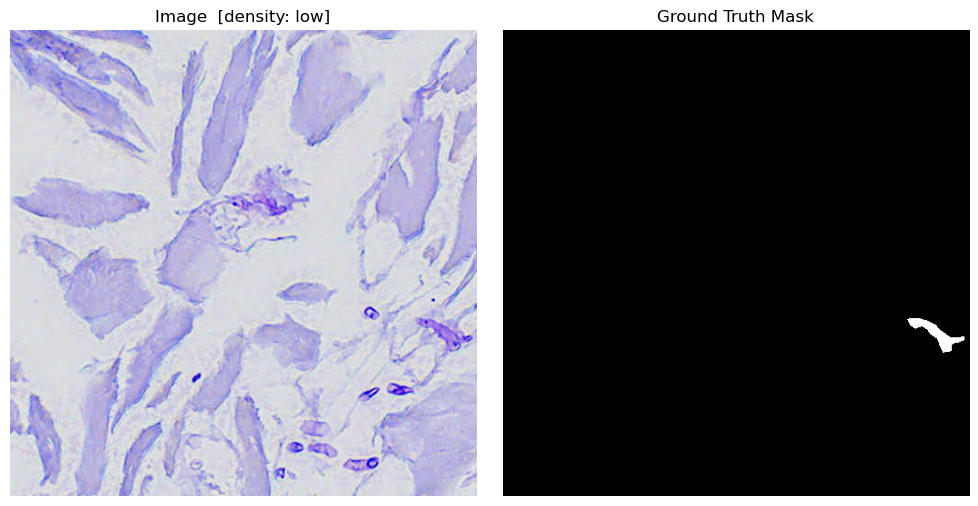

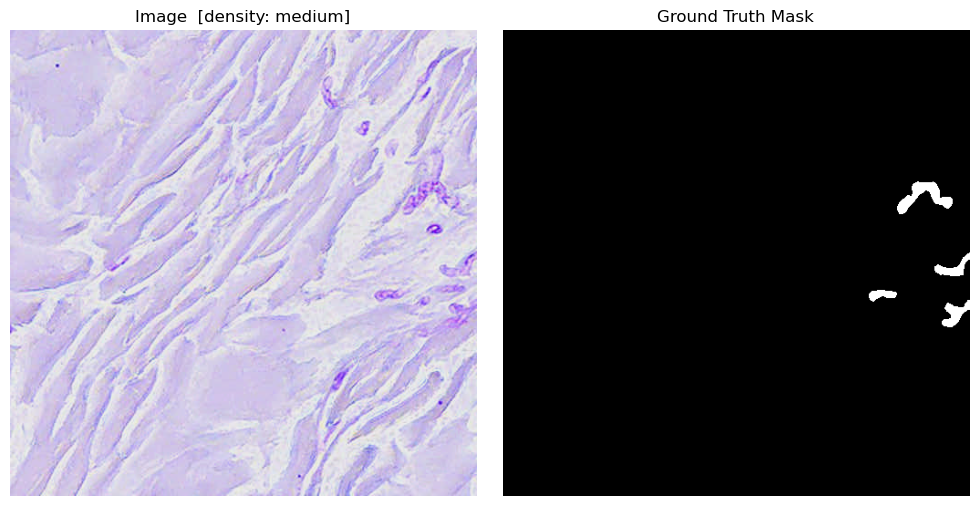

In [14]:
# Visualize first 2 samples from training set
train_imgs, train_masks, train_densities = next(iter(train_loader))
density_names = {v: k for k, v in DENSITY_LABELS.items()}

for i in range(min(2, train_imgs.size(0))):
    img_np  = train_imgs[i].permute(1,2,0).numpy()
    img_np  = img_np * np.array([0.229, 0.224, 0.225]) + np.array([0.485, 0.456, 0.406])
    img_np  = np.clip(img_np, 0, 1)
    mask_np = train_masks[i,0].numpy()
    density = density_names[train_densities[i].item()]

    plt.figure(figsize=(10, 5))
    plt.subplot(1, 2, 1)
    plt.imshow(img_np)
    plt.title(f"Image  [density: {density}]")
    plt.axis('off')
    plt.subplot(1, 2, 2)
    plt.imshow(mask_np, cmap='gray')
    plt.title("Ground Truth Mask")
    plt.axis('off')
    plt.tight_layout()
    plt.show()


In [15]:
device    = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

model     = ResidualAttentionUNet(in_ch=3, out_ch=1, num_density_classes=4).to(device)
criterion = CombinedLoss(density_weight=0.3)

optimizer = optim.AdamW(
    model.parameters(),
    lr=1e-4,
    weight_decay=1e-4
)

# mode='min' on the negative means it tracks improvement when dice goes up.
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',          # minimizing the tracked value (-val_dice)
    factor=0.5,          # multiply LR by 0.5 on plateau
    patience=5,          # epochs to wait before reducing
    min_lr=1e-7,         # floor for LR
)
def denormalize(tensor):
    img = tensor.permute(1,2,0).numpy()
    img = img * np.array([0.229, 0.224, 0.225]) + np.array([0.485, 0.456, 0.406])
    return np.clip(img, 0, 1)
print(f"\nModel params: {sum(p.numel() for p in model.parameters()):,}")
print(f"Optimizer   : AdamW  lr=1e-4  wd=1e-4")
print(f"Scheduler   : ReduceLROnPlateau  factor=0.5  patience=5")

Device: cuda

Model params: 34,242,739
Optimizer   : AdamW  lr=1e-4  wd=1e-4
Scheduler   : ReduceLROnPlateau  factor=0.5  patience=5


In [16]:
EPOCHS            = 50
CHECKPOINT_PATH   = "best_unet_checkpoint.pth"
EARLY_STOP_PATIENCE = 15  

# ---- History tracking ----
history = {
    "train_loss": [], "train_dice": [], "train_iou": [],
    "val_loss":   [], "val_dice":   [], "val_iou":   [],
    "lr":         []
}

best_val_dice    = -1.0
no_improve_count = 0

print("=" * 60)
print("Starting Training")
print("=" * 60)

for epoch in range(1, EPOCHS + 1):
    current_lr = optimizer.param_groups[0]["lr"]
    print(f"\n{'='*60}")
    print(f"Epoch {epoch}/{EPOCHS}   |   LR = {current_lr:.2e}")
    print(f"{'='*60}")

    # --- Train ---
    train_metrics = train_one_epoch(
        model, train_loader, criterion, optimizer, device, epoch_num=epoch
    )

    # --- Validate ---
    val_metrics = evaluate(model, val_loader, criterion, device)

    # --- Scheduler step ---
    # Use val_dice if available, else fall back to train_dice
    if val_metrics:
        sched_metric = -val_metrics["dice"]   # negate so plateau = dice not improving
    else:
        sched_metric = -train_metrics["dice"]
    scheduler.step(sched_metric)
    history["lr"].append(current_lr)

    # --- Log history ---
    history["train_loss"].append(train_metrics["loss"])
    history["train_dice"].append(train_metrics["dice"])
    history["train_iou"].append(train_metrics["iou"])

    if val_metrics:
        history["val_loss"].append(val_metrics["loss"] if val_metrics else None)
        history["val_dice"].append(val_metrics["dice"] if val_metrics else None)
        history["val_iou"].append(val_metrics["iou"]  if val_metrics else None)

    # --- Print epoch summary ---
    print(f"\nEpoch {epoch} Summary:")
    print(f"  Train  →  loss={train_metrics['loss']:.4f}  dice={train_metrics['dice']:.4f}  iou={train_metrics['iou']:.4f}")
    if val_metrics:
        print(f"  Val    →  loss={val_metrics['loss']:.4f}  dice={val_metrics['dice']:.4f}  iou={val_metrics['iou']:.4f}")
        print(f"             precision={val_metrics['precision']:.4f}  recall={val_metrics['recall']:.4f}")

    # --- Best model checkpoint ---
    monitor_dice = val_metrics["dice"] if val_metrics else train_metrics["dice"]
    if monitor_dice > best_val_dice:
        best_val_dice = monitor_dice
        no_improve_count = 0
        torch.save({
            "epoch":                epoch,
            "model_state_dict":     model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "scheduler_state_dict": scheduler.state_dict(),
            "best_dice":            best_val_dice,
            "history":              history,
            "img_size":             IMG_SIZE,        
            "batch_size":           BATCH_SIZE,
        }, CHECKPOINT_PATH)
        print(f"  ✅  New best dice={best_val_dice:.4f} — checkpoint saved.")
    else:
        no_improve_count += 1
        print(f"  ⏳  No improvement ({no_improve_count}/{EARLY_STOP_PATIENCE}). Best dice={best_val_dice:.4f}")

    # --- Early stopping ---
    if no_improve_count >= EARLY_STOP_PATIENCE:
        print(f"\n🛑 Early stopping triggered after {epoch} epochs.")
        break

print("\n" + "=" * 60)
print(f"Training complete. Best dice: {best_val_dice:.4f}")
print(f"Best checkpoint: {CHECKPOINT_PATH}")
print("=" * 60)

Starting Training

Epoch 1/50   |   LR = 1.00e-04
  [Epoch 1 | Batch 1/8] loss=1.2413  seg=0.8506  density=1.3025  dice=0.1512  iou=0.1064
  [Epoch 1 | Batch 2/8] loss=1.4238  seg=0.9838  density=1.4669  dice=0.0140  iou=0.0070
  [Epoch 1 | Batch 3/8] loss=0.8978  seg=0.6674  density=0.7679  dice=0.4689  iou=0.4349
  [Epoch 1 | Batch 4/8] loss=1.2353  seg=0.9882  density=0.8237  dice=0.0188  iou=0.0096
  [Epoch 1 | Batch 5/8] loss=1.0024  seg=0.6344  density=1.2265  dice=0.4928  iou=0.4737
  [Epoch 1 | Batch 6/8] loss=1.5072  seg=0.9880  density=1.7308  dice=0.0166  iou=0.0084
  [Epoch 1 | Batch 7/8] loss=1.7034  seg=0.9759  density=2.4250  dice=0.0795  iou=0.0455
  [Epoch 1 | Batch 8/8] loss=1.0877  seg=0.6624  density=1.4176  dice=0.3919  iou=0.3115

Epoch 1 Summary:
  Train  →  loss=1.2624  dice=0.2042  iou=0.1746
  Val    →  loss=1.3093  dice=0.0382  iou=0.0343
             precision=0.0343  recall=0.9655
  ✅  New best dice=0.0382 — checkpoint saved.

Epoch 2/50   |   LR = 1.00e-04

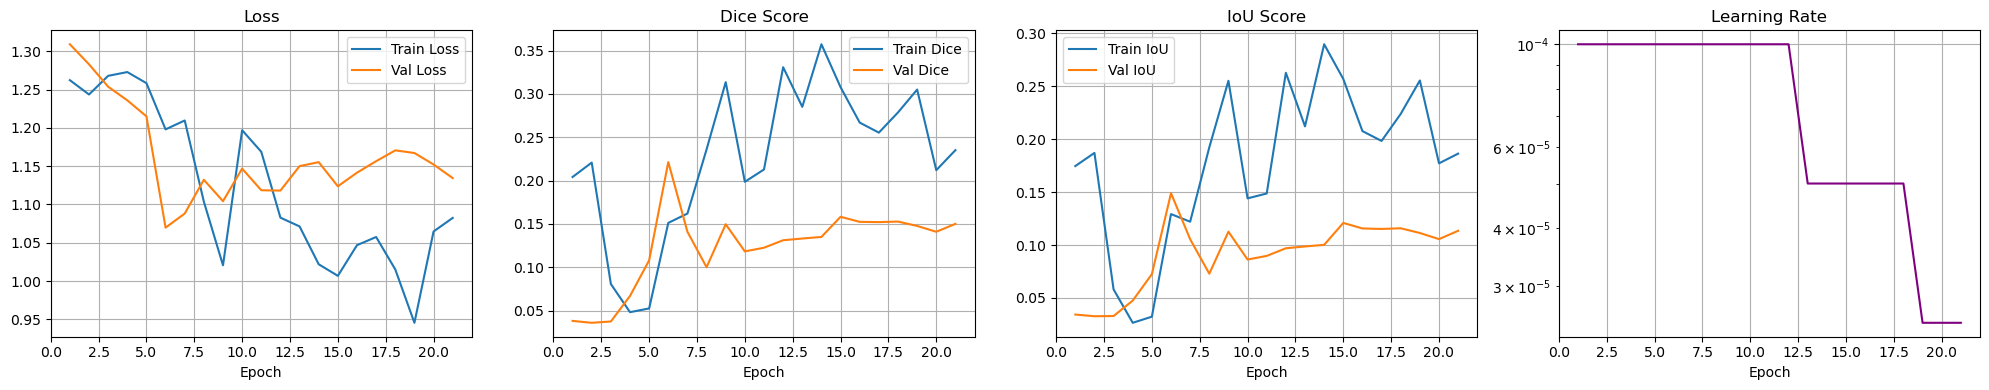

Curves saved to training_curves.png


In [17]:
# plot training curves
fig, axes = plt.subplots(1, 4, figsize=(20, 4))

epochs_range = range(1, len(history["train_loss"]) + 1)

# Loss
axes[0].plot(epochs_range, history["train_loss"], label="Train Loss")
if history["val_loss"]:
    axes[0].plot(epochs_range, history["val_loss"], label="Val Loss")
axes[0].set_title("Loss")
axes[0].set_xlabel("Epoch")
axes[0].legend()
axes[0].grid(True)

# Dice
axes[1].plot(epochs_range, history["train_dice"], label="Train Dice")
if history["val_dice"]:
    axes[1].plot(epochs_range, history["val_dice"], label="Val Dice")
axes[1].set_title("Dice Score")
axes[1].set_xlabel("Epoch")
axes[1].legend()
axes[1].grid(True)

# IoU
axes[2].plot(epochs_range, history["train_iou"], label="Train IoU")
if history["val_iou"]:
    axes[2].plot(epochs_range, history["val_iou"], label="Val IoU")
axes[2].set_title("IoU Score")
axes[2].set_xlabel("Epoch")
axes[2].legend()
axes[2].grid(True)
#LR
axes[3].plot(epochs_range, history["lr"], label="LR", color="purple")
axes[3].set_title("Learning Rate")
axes[3].set_xlabel("Epoch")
axes[3].set_yscale("log")  # log scale makes LR drops visible
axes[3].grid(True)

plt.tight_layout()
plt.savefig("training_curves.png", dpi=150, bbox_inches="tight")
plt.show()
print("Curves saved to training_curves.png")

In [18]:
print(f"Loading best checkpoint from {CHECKPOINT_PATH}...")
checkpoint = torch.load(CHECKPOINT_PATH, map_location=device)
model.load_state_dict(checkpoint["model_state_dict"])
print(f"Loaded epoch {checkpoint['epoch']} — best dice={checkpoint['best_dice']:.4f}")

# Run final evaluation on val set
final_val = evaluate(model, val_loader, criterion, device)
if final_val:
    print("\nFinal Validation Metrics:")
    print(f"  Loss      : {final_val['loss']:.4f}")
    print(f"  Dice      : {final_val['dice']:.4f}")
    print(f"  IoU       : {final_val['iou']:.4f}")
    print(f"  Precision : {final_val['precision']:.4f}")
    print(f"  Recall    : {final_val['recall']:.4f}")
else:
    print("No validation loader — skipping final eval.")

Loading best checkpoint from best_unet_checkpoint.pth...
Loaded epoch 6 — best dice=0.2214

Final Validation Metrics:
  Loss      : 1.0698
  Dice      : 0.2214
  IoU       : 0.1490
  Precision : 0.1831
  Recall    : 0.8578


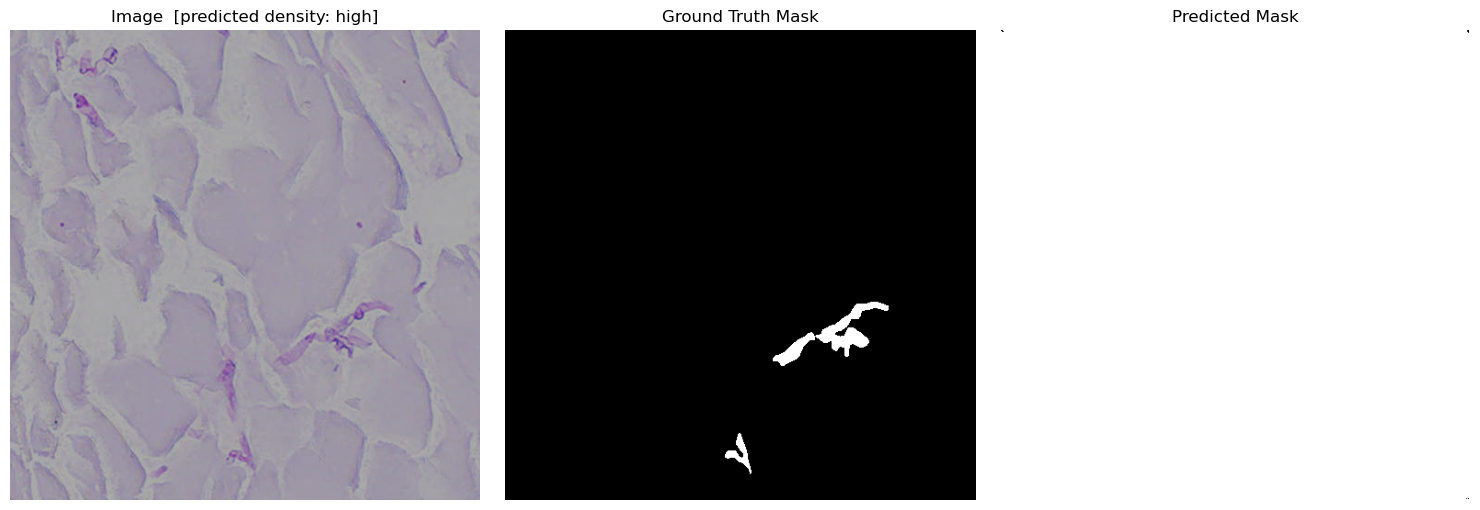

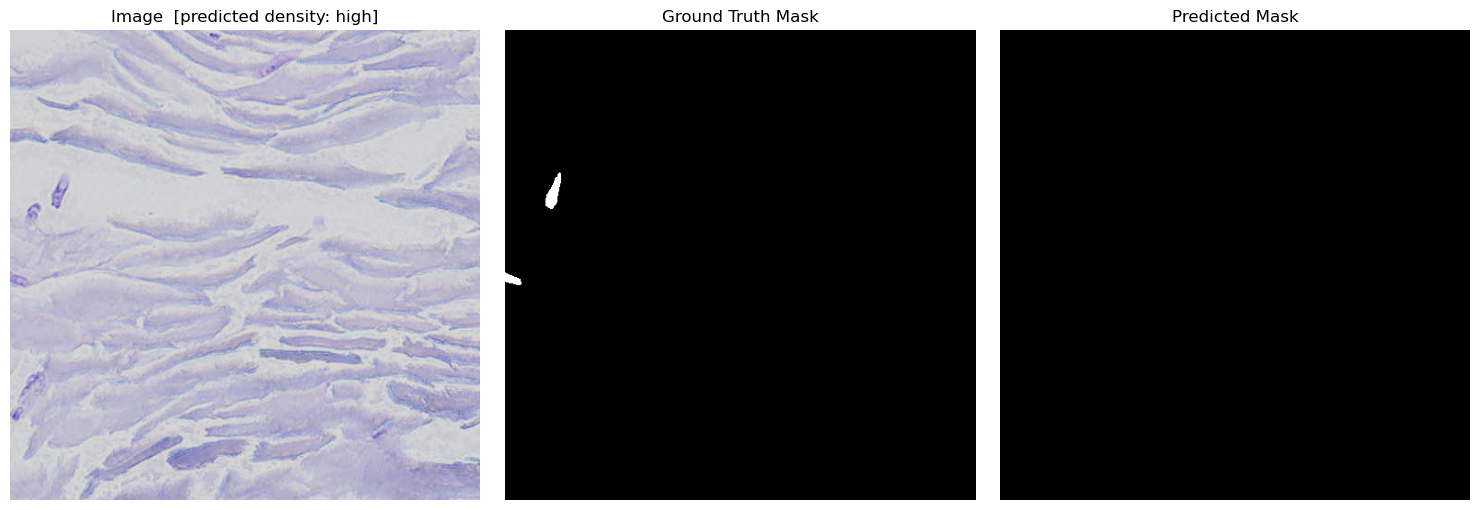

In [19]:
# Put model in evaluation mode
model.eval()

# Get one batch — now unpacks 3-tuple
imgs, masks, densities = next(iter(train_loader))
imgs      = imgs.to(device)
masks     = masks.to(device)
densities = densities.to(device)

# Run inference — model now requires density labels
with torch.no_grad():
    seg_logits, density_logits, _, _ = model(imgs)  # _ discards aux outputs
    preds_sigmoid = torch.sigmoid(seg_logits)
    predicted_densities = density_logits.argmax(dim=1)

# Threshold at 0.5
preds_bin = (preds_sigmoid > 0.5).float()

density_names = {v: k for k, v in DENSITY_LABELS.items()}

for i in range(min(2, imgs.size(0))):
    img_np  = imgs[i].cpu().permute(1,2,0).numpy()
    img_np  = img_np * np.array([0.229, 0.224, 0.225]) + np.array([0.485, 0.456, 0.406])
    img_np  = np.clip(img_np, 0, 1)
    mask_np = masks[i,0].cpu().numpy()
    pred_np = preds_bin[i,0].cpu().numpy()
    density = density_names[predicted_densities[i].item()]

    plt.figure(figsize=(15, 5))

    plt.subplot(1, 3, 1)
    plt.imshow(img_np)
    plt.title(f"Image  [predicted density: {density}]")
    plt.axis('off')

    plt.subplot(1, 3, 2)
    plt.imshow(mask_np, cmap='gray')
    plt.title("Ground Truth Mask")
    plt.axis('off')

    plt.subplot(1, 3, 3)
    plt.imshow(pred_np, cmap='gray')
    plt.title("Predicted Mask")
    plt.axis('off')

    plt.tight_layout()
    plt.show()

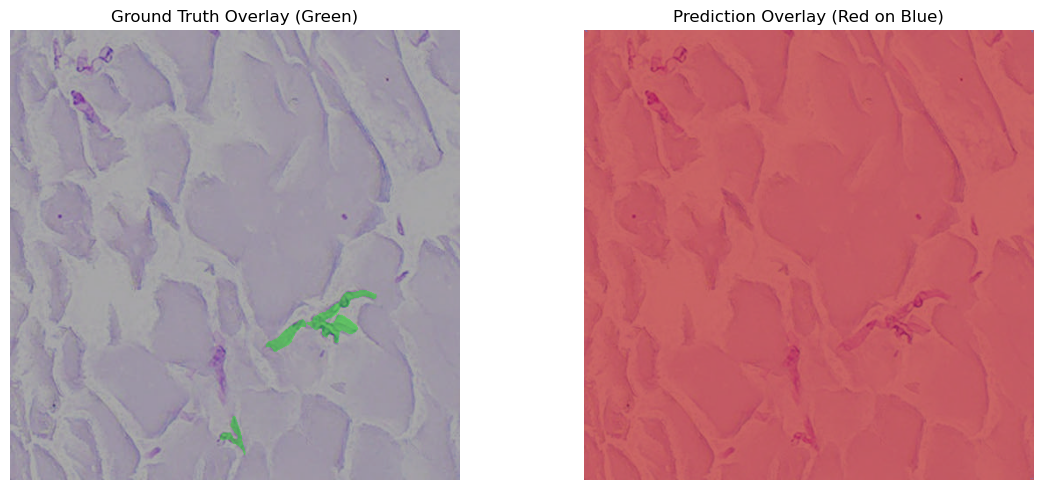

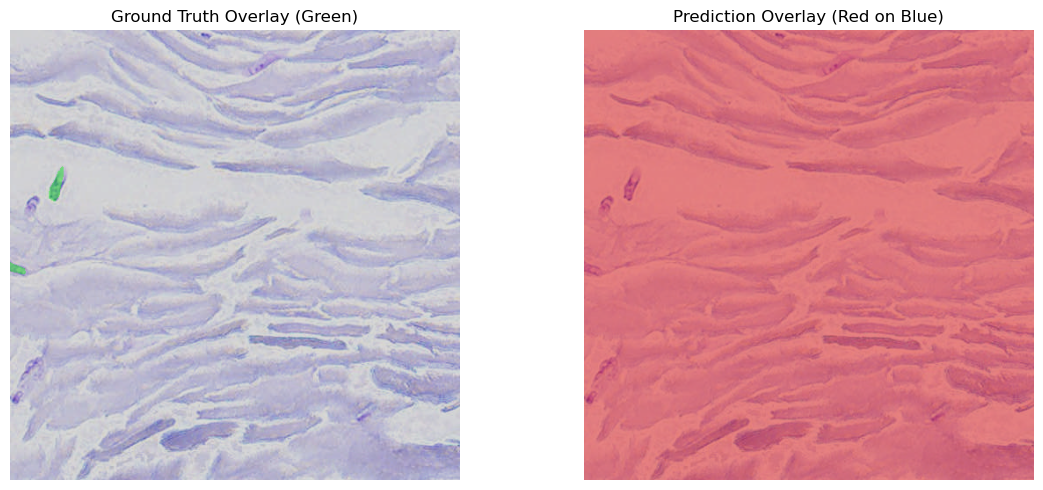

In [20]:
def overlay_mask(image_tensor, mask_tensor, color=[1,0,0], alpha=0.4, bg_tint=None, bg_alpha=0.2):
    """
    Overlay a binary mask on an image.
    
    Args:
        image_tensor: Input image tensor
        mask_tensor: Binary mask tensor
        color: RGB color for the mask overlay
        alpha: Opacity of the mask overlay
        bg_tint: Optional RGB color to tint the background (non-mask areas)
        bg_alpha: Opacity of the background tint
    """
    # Denormalize the image
    img = image_tensor.cpu().permute(1,2,0).numpy()
    img = img * np.array([0.229, 0.224, 0.225]) + np.array([0.485, 0.456, 0.406])
    img = np.clip(img, 0, 1)
    
    # Upsample mask if needed
    if mask_tensor.shape != image_tensor.shape[1:]:
        mask_tensor = F.interpolate(
            mask_tensor.unsqueeze(0).unsqueeze(0),
            size=image_tensor.shape[1:],
            mode='bilinear',
            align_corners=False
        ).squeeze()
    
    mask = mask_tensor.cpu().numpy()
    overlay = img.copy()
    
    for c in range(3):
        if bg_tint is not None:
            # Apply mask color where mask > 0, and background tint where mask == 0
            overlay[:,:,c] = np.where(
                mask > 0, 
                img[:,:,c] * (1 - alpha) + color[c] * alpha,  # Mask areas
                img[:,:,c] * (1 - bg_alpha) + bg_tint[c] * bg_alpha  # Background areas
            )
        else:
            # Original behavior - only overlay the mask
            overlay[:,:,c] = np.where(
                mask > 0, 
                img[:,:,c] * (1 - alpha) + color[c] * alpha, 
                img[:,:,c]
            )
    
    return overlay

# Visualize with overlays
for i in range(min(2, imgs.size(0))):
    img = imgs[i]
    mask_gt = masks[i,0]
    mask_pred = preds_bin[i,0]
    
    overlay_gt = overlay_mask(img, mask_gt, color=[0,1,0], alpha=0.4)    # Green
    overlay_pred = overlay_mask(img, mask_pred, color=[1,0,0], alpha=0.4, 
                                bg_tint=[0,0,1], bg_alpha=0.2)  # Red with blue background
    
    plt.figure(figsize=(12, 5))
    
    plt.subplot(1, 2, 1)
    plt.imshow(overlay_gt)
    plt.title("Ground Truth Overlay (Green)")
    plt.axis('off')
    
    plt.subplot(1, 2, 2)
    plt.imshow(overlay_pred)
    plt.title("Prediction Overlay (Red on Blue)")
    plt.axis('off')
    
    plt.tight_layout()
    plt.show()

In [21]:
| Date | Location | Issue | Severity | Status |
|------|----------|-------|----------|--------|
| 02-25-26 | WSIDatasetIndex | Duplicate detection never triggered on Path objects | High | Fixed |
| 02-25-26 | WSIDatasetIndex | Silent exception swallowing on corrupt files | High | Fixed |
| 02-25-26 | WSIDatasetIndex | TilePair __post_init__ doing disk I/O, breaks JSON reload | Medium | Fixed |
| 02-25-26 | WSIDatasetIndex | Incomplete case-insensitive mask matching on Linux | Medium | Fixed |
| 02-25-26 | WSIDatasetIndex | strict_mode=True + allow_size_mismatch=True conflict | Medium | Resolved by setting allow_size_mismatch=False |
| 02-25-26 | get_train_val_split | random.shuffle replaced with numpy default_rng for version stability | Medium | Fixed |
| 02-25-26 | _validate_tile_pair | Mismatched quotes syntax error in RuntimeError | High | Fixed |
| 02-25-26 | _validate_tile_pair | duplicates variable undefined after duplicate detection rewrite | High | Fixed |
| 02-25-26 | AugmentedWSI_Dataset | ColorJitter instantiated on every __getitem__ call | Medium | Fixed |
| 02-25-26 | train_one_epoch | log_interval computed twice inside loop | Low | Fixed |
| 02-25-26 | train_one_epoch | Old variable names d/iou in print after switching to compute_all_metrics | High | Fixed |
| 02-25-26 | train_one_epoch | Per-batch printing replaced with log_interval | Low | Fixed |
| 02-25-26 | evaluate | Consolidated 4 separate metric calls into compute_all_metrics | Low | Fixed |
| 02-25-26 | Training loop | LR logged before scheduler step, one epoch behind | Medium | Fixed |
| 02-25-26 | Training loop | val history length could desync from train if val unavailable | Medium | Fixed |
| 02-25-26 | Training loop | Checkpoint missing img_size and batch_size hyperparameters | Medium | Fixed |
| 02-25-26 | Training loop | alpha/beta swapped between class definition and instantiation | High | Flagged |
| 02-25-26 | Plotting | LR curve tracked but never plotted | Low | Fixed |
| 02-25-26 | Plotting | subplots created with size 3 but 4 axes needed | High | Fixed |
| 02-25-26 | FocalTverskyLoss | alpha/beta convention intentionally penalizes FN more | Note | Documented |
| 02-25-26 | Notebook structure | Cell execution order caused NameError for dice_score | High | Fixed |
| 03-03-26 | FocalTverskyLoss | Replaced with AsymmetricSimilarityLoss — density-aware α/β per tile | High | Fixed |
| 03-03-26 | ResidualAttentionUNet | Added DensityEmbedding module injected at bottleneck for density conditioning | High | Fixed |
| 03-03-26 | ResidualAttentionUNet | forward() missing density_label argument — model called as model(imgs) in train_one_epoch and evaluate | High | Fixed |
| 03-03-26 | TilePair | Missing density field — tiles carried no density class through pipeline | High | Fixed |
| 03-03-26 | WSIDatasetIndex | _process_wsi_folder only looked for flat images/masks dirs, not density subfolders | High | Fixed |
| 03-03-26 | WSIDatasetIndex | validation_report missing density_counts field | Low | Fixed |
| 03-03-26 | WSI_Dataset | __getitem__ returned 2-tuple — density_label not passed to loss or model | High | Fixed |
| 03-03-26 | AugmentedWSI_Dataset | __getitem__ returned 2-tuple — density_label not passed to loss or model | High | Fixed |
| 03-03-26 | DataLoader | shuffle=True replaced with WeightedRandomSampler for density class balance | Medium | Fixed |
| 03-03-26 | get_train_val_split | Single-WSI edge case left train_pairs empty, causing num_samples=0 in sampler | High | Fixed |
| 03-03-26 | QuPath export script | Tiles exported to single flat folder with no density labeling | High | Fixed — classify_tiles.py added as post-processing step |
| 03-03-26 | classify_tiles.py | Tile classification used own coverage only, missing neighbourhood density context | Medium | Fixed — context-weighted score using 8-neighbour mean |
| 03-06-26 | AsymmetricSimilarityLoss | Docstring had α/β definitions inverted — α weights FN (sensitivity), β weights FP (conservatism), not the reverse | High | Fixed — resolves flagged 02-25-26 entry |
| 03-06-26 | ResidualAttentionUNet | Added density_head classification branch to bottleneck for single-pass inference density self-prediction | High | Fixed |
| 03-06-26 | ResidualAttentionUNet | forward() now returns 2-tuple (seg_logits, density_logits) — sanity check used out.shape directly on tuple | Medium | Fixed |
| 03-06-26 | ResidualAttentionUNet | forward() indentation error — entire method body unindented relative to class | High | Fixed |
| 03-06-26 | CombinedLoss | Added to replace bare AsymmetricSimilarityLoss — wraps segmentation and density classification losses with configurable density_weight | High | Fixed |
| 03-06-26 | train_one_epoch | Updated to unpack (seg_logits, density_logits) tuple and log seg/density loss components separately | Medium | Fixed |
| 03-06-26 | evaluate | running_seg_loss and running_density_loss not initialised — NameError on return | High | Fixed |
| 03-06-26 | evaluate | Updated to unpack (seg_logits, density_logits) and pass both to CombinedLoss | Medium | Fixed |
| 03-06-26 | Cell 17 inference | model(imgs, densities) replaced with model(imgs) — density_label=None triggers self-prediction at inference | Medium | Fixed |

SyntaxError: leading zeros in decimal integer literals are not permitted; use an 0o prefix for octal integers (1828781436.py, line 3)